<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/01_var_sync_crisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Índices disponibles para el análisis:
  1. SP500
  2. DJIA
  3. NASDAQ
  4. FTSE100
  5. CAC40
  6. DAX
  7. NIKKEI225
  8. IPC_Mexico
  9. ASX200
  10. SSE_Composite
  11. BOVESPA
  12. TSX_Canada
  all. Todos los índices

> Introduce los números de los índices que deseas analizar, separados por comas (e.g., 1,3,8), o escribe 'all' para todos: all

Has seleccionado: SP500, DJIA, NASDAQ, FTSE100, CAC40, DAX, NIKKEI225, IPC_Mexico, ASX200, SSE_Composite, BOVESPA, TSX_Canada

1. Descargando datos de precios...


/tmp/ipython-input-1742504018.py:76: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precios = yf.download(list(tickers.values()), start=fecha_inicio, end=fecha_fin)['Close']
[*********************100%***********************]  12 of 12 completed


2. Calculando rendimientos logarítmicos...
3. Calculando el cuantil 5.0% (VaR Histórico)...
4. Generando gráficos...


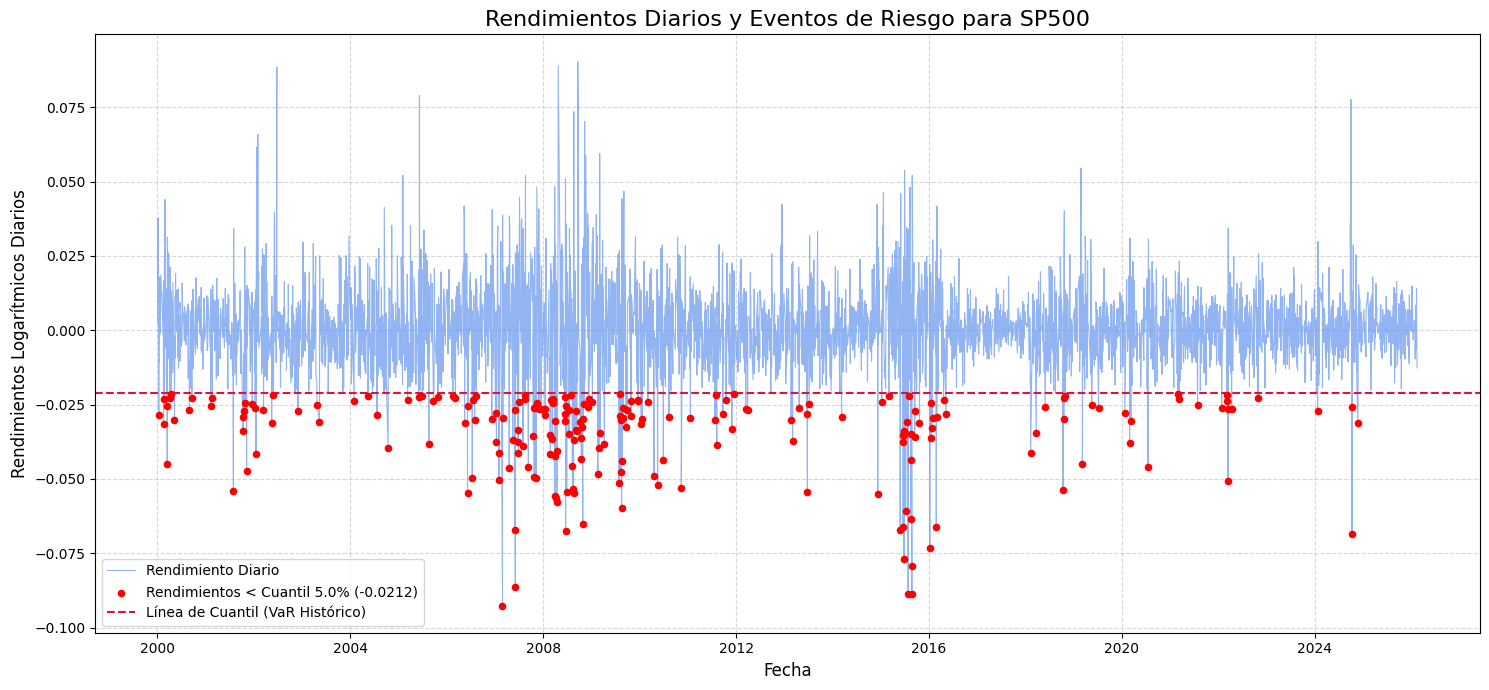

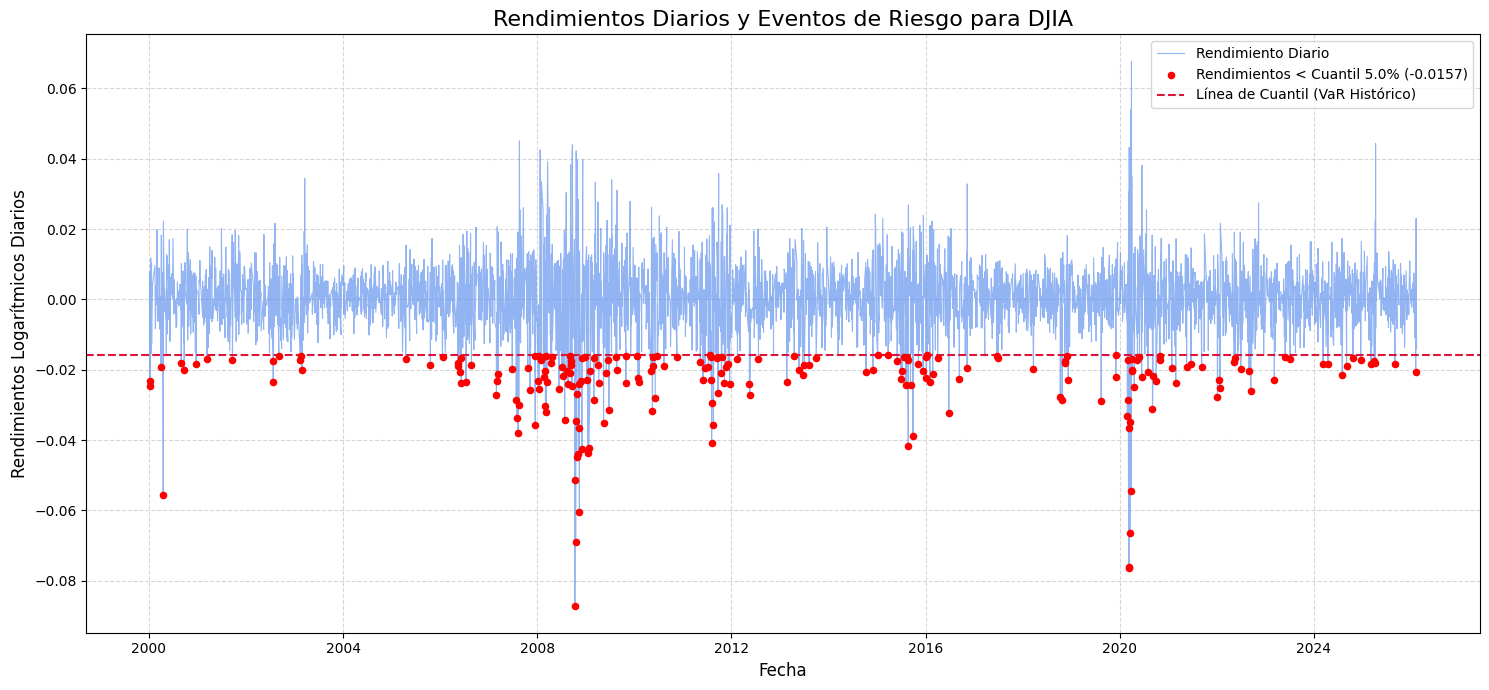

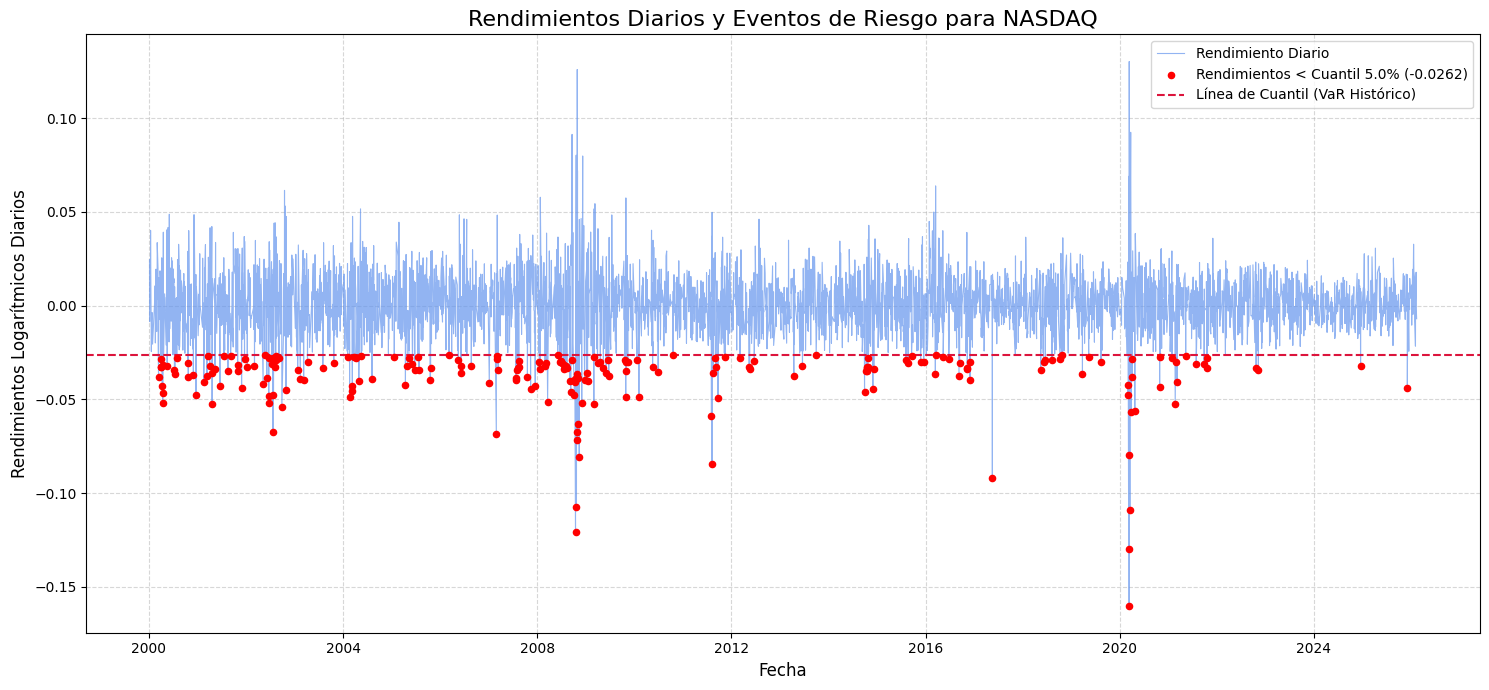

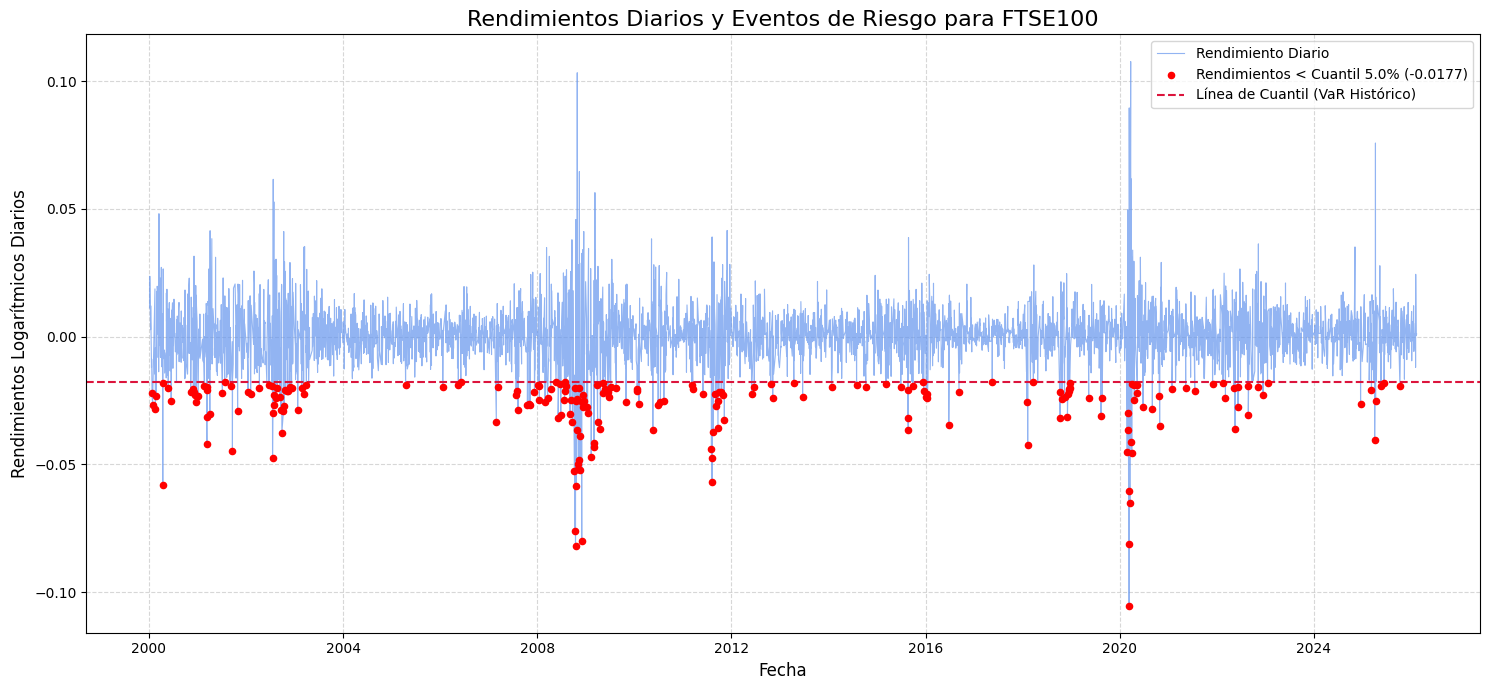

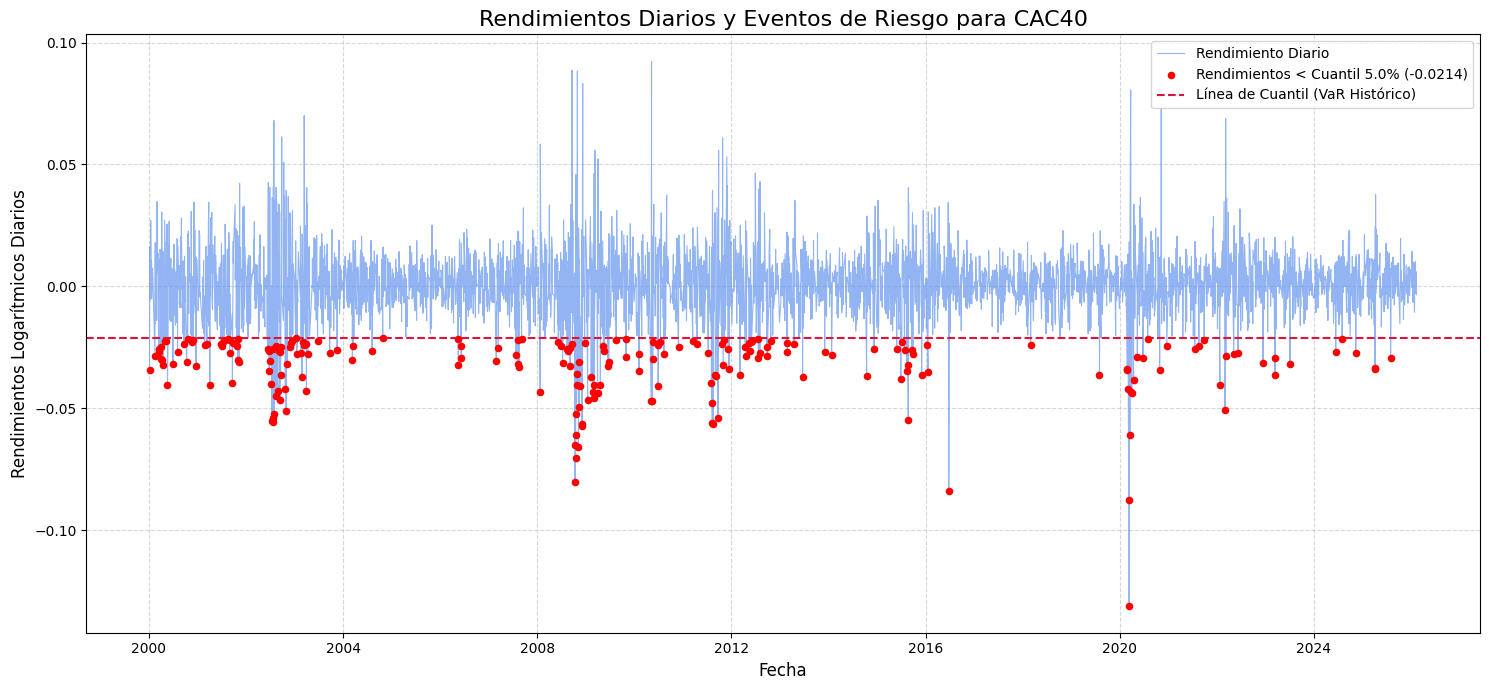

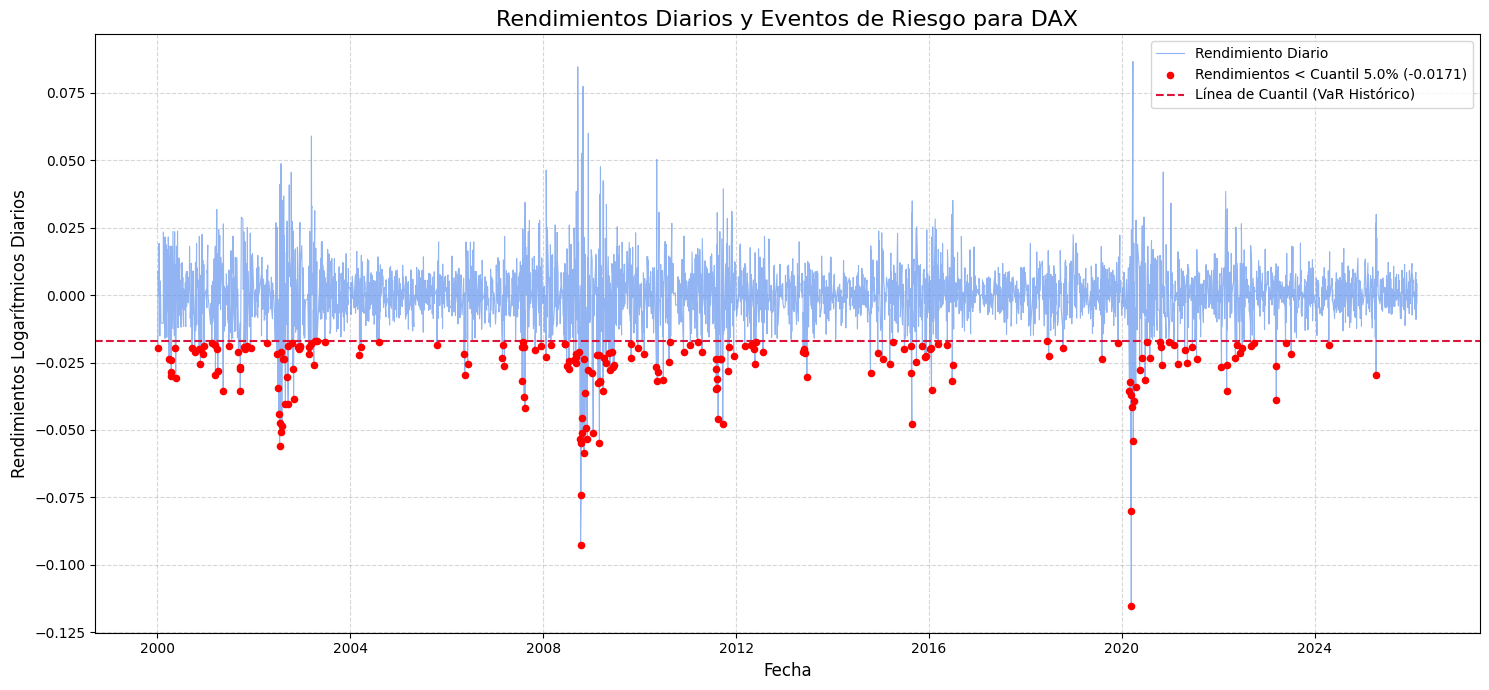

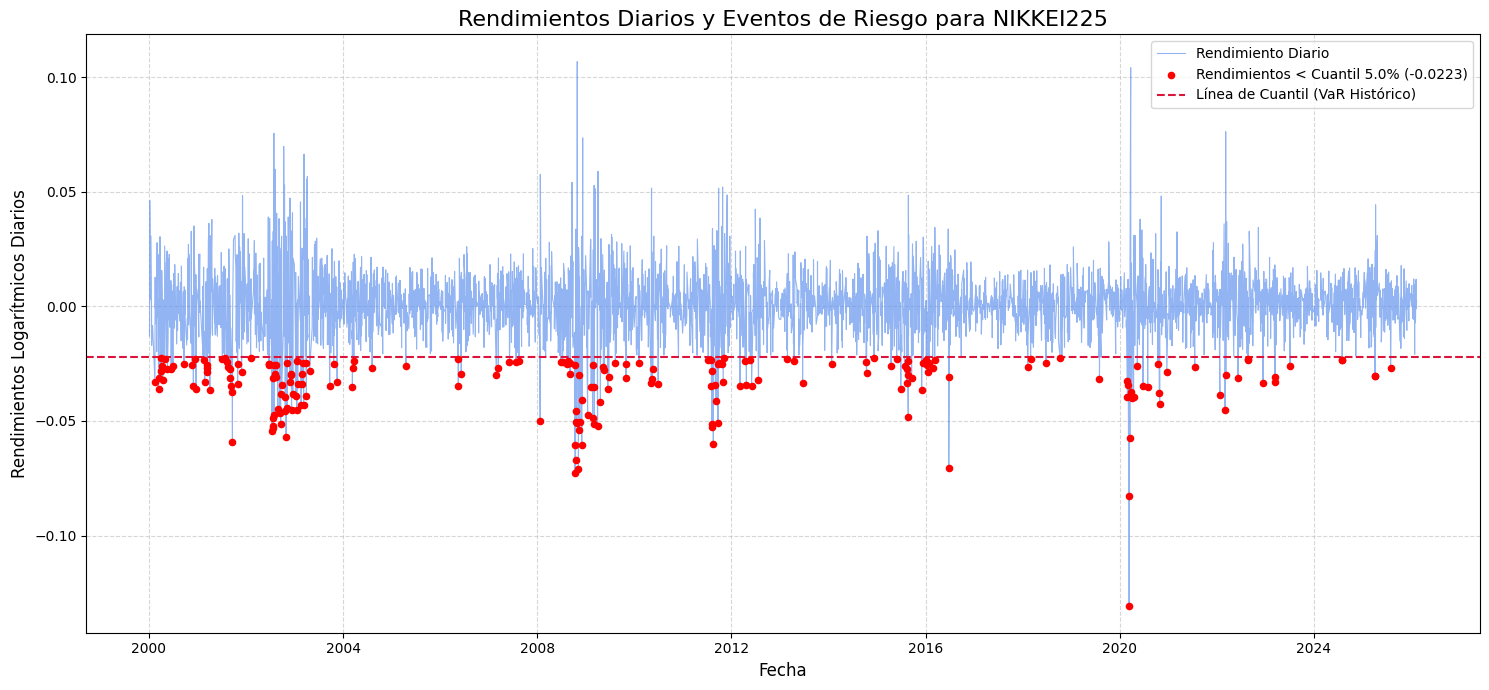

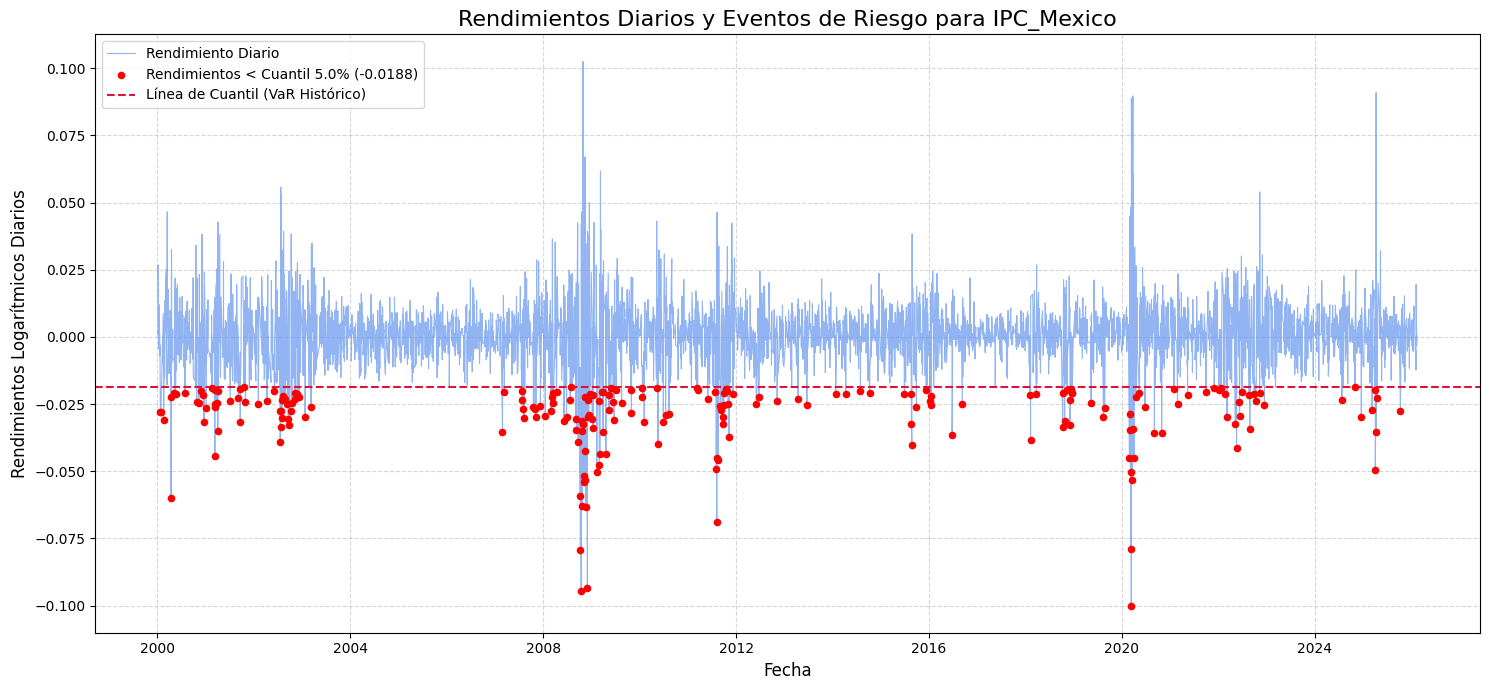

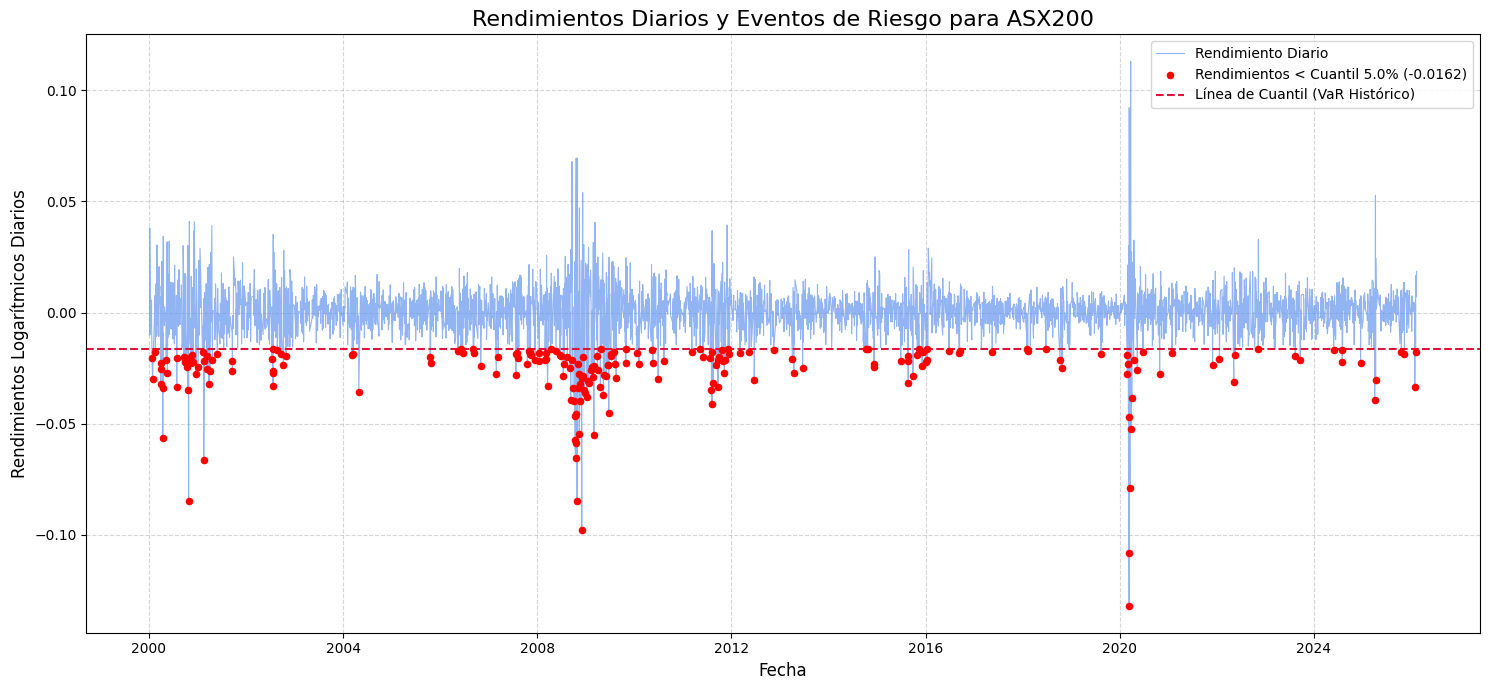

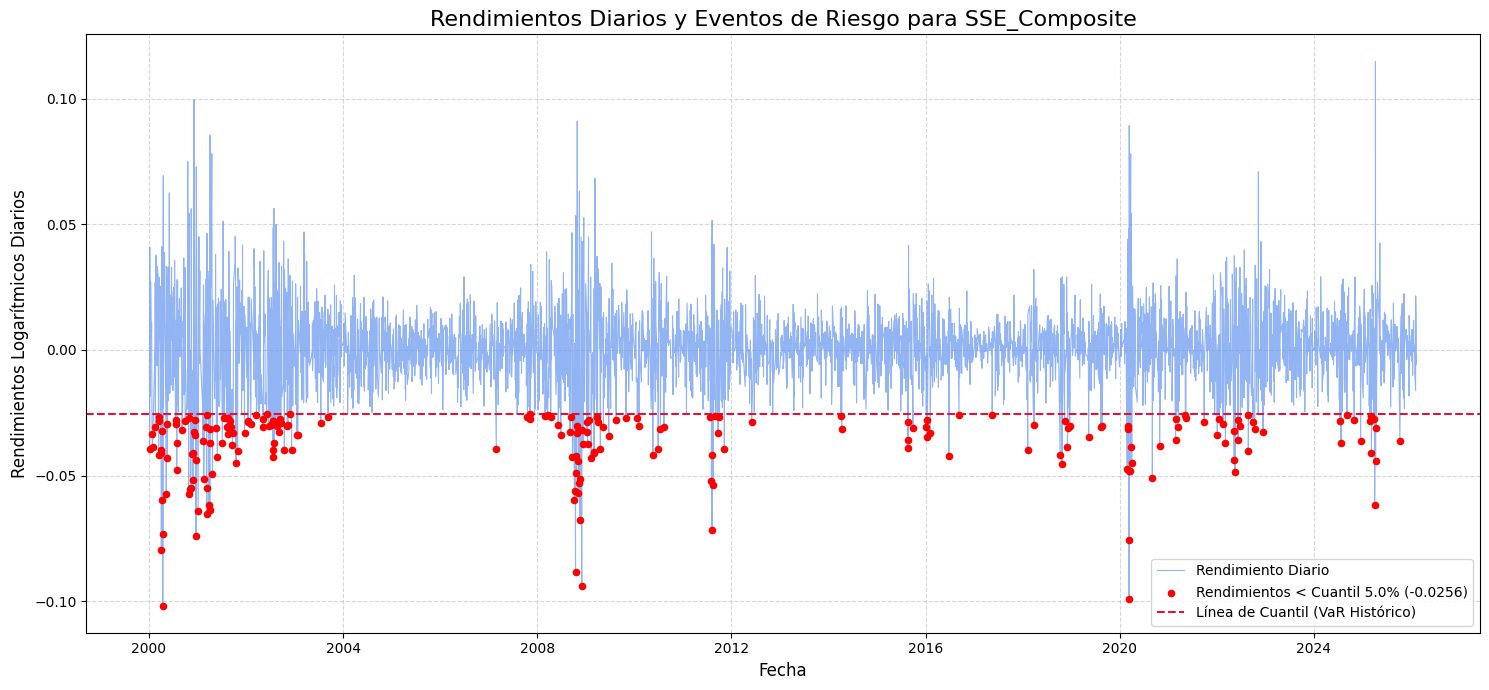

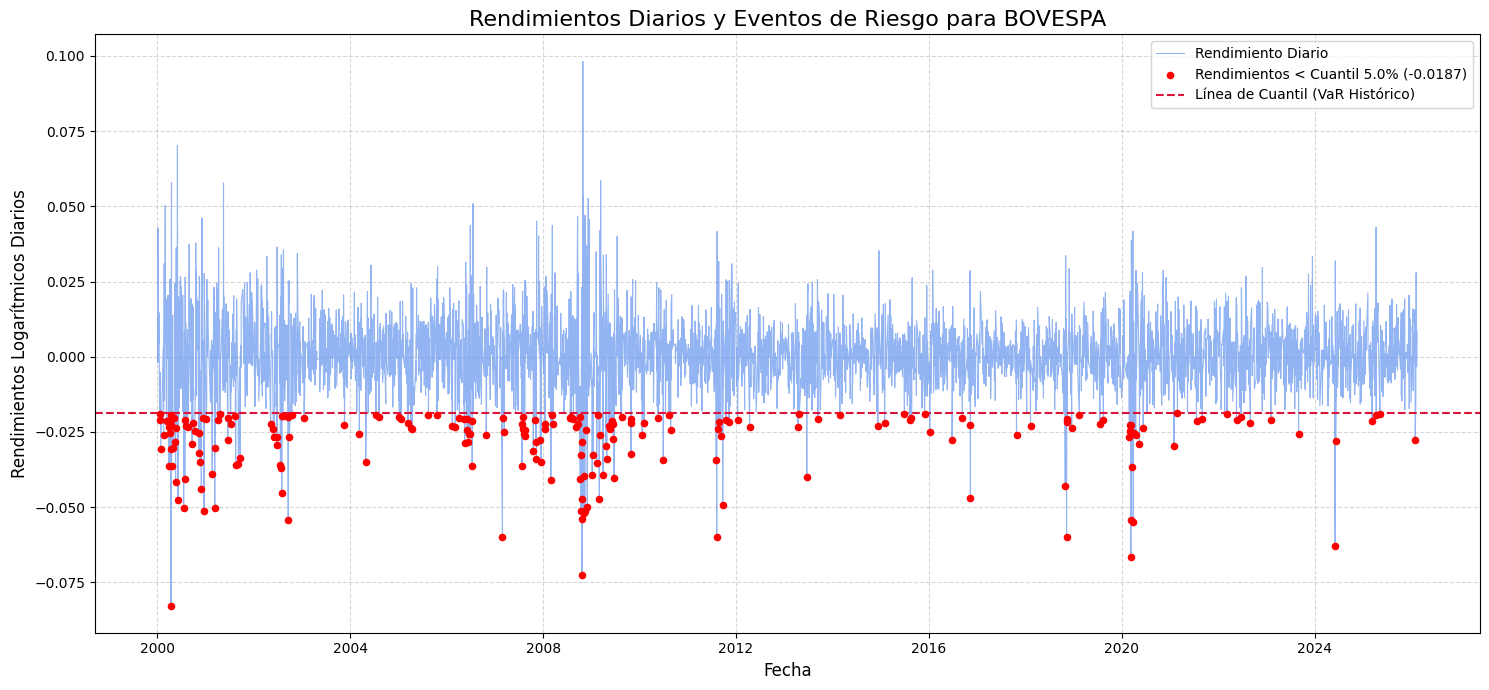

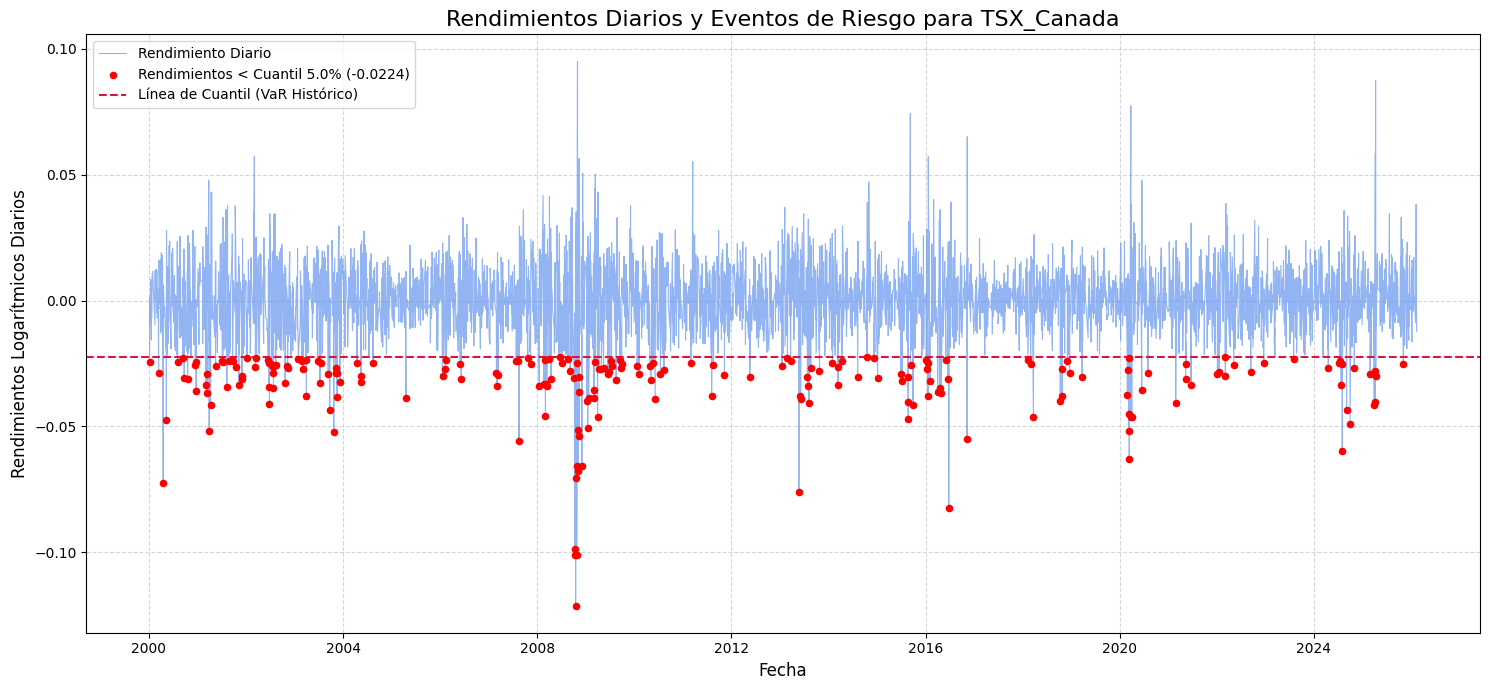

5. Exportando fechas críticas a 'Reporte_Fechas_Criticas.xlsx'...
Exportación completada con éxito.


In [ ]:
# -*- coding: utf-8 -*-
"""
Análisis de Riesgo de Índices Bursátiles Globales
"""

# MÓDULO 1: IMPORTACIÓN DE BIBLIOTECAS
# -----------------------------------------------------------------------------
# Se importan las bibliotecas necesarias para el análisis.
# pandas: Para la manipulación y análisis de datos, especialmente series de tiempo.
# yfinance: Para descargar datos históricos del mercado desde Yahoo! Finance.
# numpy: Para cálculos numéricos eficientes, en este caso, el cuantil.
# matplotlib.pyplot: Para la creación de gráficos y visualizaciones.
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# MÓDULO 2: CONFIGURACIÓN GLOBAL
# -----------------------------------------------------------------------------
# En esta sección se definen los parámetros principales que el usuario puede modificar.
class Configuracion:
    """
    Clase para almacenar todas las configuraciones del análisis.
    Esto permite una fácil modificación de los parámetros en un solo lugar.
    """
    # Define el diccionario de índices a analizar.
    # La clave es el nombre común del índice y el valor es su ticker en Yahoo Finance.
    # Nota: El usuario pidió FTSE500, pero el índice principal del Reino Unido es el FTSE 100.
    # Usaremos el FTSE 100 (^FTSE) como el estándar de la industria.
    INDICES = {
        'SP500': '^GSPC',
        'DJIA': '^DJI',
        'NASDAQ': '^IXIC',
        'FTSE100': '^FTSE', # Corregido de FTSE500 a FTSE100
        'CAC40': '^FCHI',
        'DAX': '^GDAXI',
        'NIKKEI225': '^N225',
        'IPC_Mexico': '^MXX',
        'ASX200': '^AXJO',
        'SSE_Composite': '000001.SS',
        'BOVESPA': '^BVSP',
        'TSX_Canada': '^GSPTSE',
    }

    # Define el rango de fechas para el análisis.
    FECHA_INICIO = '2000-01-01'
    FECHA_FIN = pd.to_datetime('today').strftime('%Y-%m-%d') # Usa la fecha actual como fin

    # Define el cuantil para el análisis de riesgo (e.g., 0.05 para el 5% VaR).
    CUANTIL = 0.05

    # Define el nombre del archivo de salida para el reporte en Excel.
    NOMBRE_ARCHIVO_EXCEL = 'Reporte_Fechas_Criticas.xlsx'

# MÓDULO 3: PROCESAMIENTO Y CÁLCULO DE DATOS
# -----------------------------------------------------------------------------
def obtener_y_procesar_datos(tickers, fecha_inicio, fecha_fin, cuantil):
    """
    Descarga los datos de precios, calcula los rendimientos logarítmicos
    y el cuantil (VaR histórico) para cada índice.

    Args:
        tickers (dict): Diccionario con nombres y tickers de los índices.
        fecha_inicio (str): Fecha de inicio en formato 'YYYY-MM-DD'.
        fecha_fin (str): Fecha de fin en formato 'YYYY-MM-DD'.
        cuantil (float): El nivel de cuantil a calcular (entre 0 y 1).

    Returns:
        tuple: Una tupla conteniendo:
            - pd.DataFrame: DataFrame de rendimientos diarios.
            - pd.Series: Serie con el valor del cuantil para cada índice.
    """
    print("1. Descargando datos de precios...")
    # Se descarga el precio de cierre ajustado ('Close') para todos los tickers.
    try:
        precios = yf.download(list(tickers.values()), start=fecha_inicio, end=fecha_fin)['Close']
        # Renombra las columnas a nombres legibles usando el diccionario de tickers.
        precios.columns = list(tickers.keys())
    except Exception as e:
        print(f"Error al descargar los datos: {e}")
        return None, None

    print("2. Calculando rendimientos logarítmicos...")
    # Se calculan los rendimientos logarítmicos. Son preferidos por su aditividad temporal.
    # Se eliminan los valores NaN que resultan del primer día de cálculo.
    rendimientos = np.log(precios / precios.shift(1)).dropna()

    print(f"3. Calculando el cuantil {cuantil*100}% (VaR Histórico)...")
    # Se calcula el cuantil especificado para la serie de rendimientos de cada índice.
    cuantiles_calculados = rendimientos.quantile(cuantil)

    return rendimientos, cuantiles_calculados

# MÓDULO 4: VISUALIZACIÓN
# -----------------------------------------------------------------------------
def graficar_rendimientos_con_cuantil(rendimientos, cuantiles, indices_a_graficar):
    """
    Genera un gráfico para cada índice seleccionado, mostrando sus rendimientos
    diarios y destacando los puntos que caen por debajo del cuantil.

    Args:
        rendimientos (pd.DataFrame): DataFrame de rendimientos diarios.
        cuantiles (pd.Series): Serie con los valores de cuantil para cada índice.
        indices_a_graficar (list): Lista de nombres de los índices a graficar.
    """
    print("4. Generando gráficos...")
    for indice in indices_a_graficar:
        if indice not in rendimientos.columns:
            print(f"Advertencia: El índice '{indice}' no se encontró en los datos. Se omitirá.")
            continue

        # Filtra los rendimientos que están por debajo del cuantil (eventos de riesgo).
        rend_indice = rendimientos[indice]
        cuantil_valor = cuantiles[indice]
        puntos_criticos = rend_indice[rend_indice < cuantil_valor]

        # Creación del gráfico
        plt.figure(figsize=(15, 7))

        # Grafica la serie completa de rendimientos
        plt.plot(rend_indice.index, rend_indice, label='Rendimiento Diario', color='cornflowerblue', alpha=0.7, lw=0.8)

        # Destaca los puntos por debajo del cuantil con marcadores rojos
        plt.scatter(puntos_criticos.index, puntos_criticos, color='red', s=20, zorder=5, label=f'Rendimientos < Cuantil {Configuracion.CUANTIL*100:.1f}% ({cuantil_valor:.4f})')

        # Dibuja la línea horizontal del VaR (cuantil)
        plt.axhline(y=cuantil_valor, color='crimson', linestyle='--', linewidth=1.5, label=f'Línea de Cuantil (VaR Histórico)')

        # Formato del gráfico
        plt.title(f'Rendimientos Diarios y Eventos de Riesgo para {indice}', fontsize=16)
        plt.ylabel('Rendimientos Logarítmicos Diarios', fontsize=12)
        plt.xlabel('Fecha', fontsize=12)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout() # Ajusta el gráfico para que todo encaje sin solaparse.

        # Muestra el gráfico
        plt.show()

# MÓDULO 5: EXPORTACIÓN
# -----------------------------------------------------------------------------
def exportar_fechas_criticas_a_excel(rendimientos, cuantiles, indices_a_exportar, nombre_archivo):
    """
    Genera un archivo Excel con las fechas y los rendimientos que cayeron
    por debajo del cuantil para los índices seleccionados.

    Args:
        rendimientos (pd.DataFrame): DataFrame de rendimientos diarios.
        cuantiles (pd.Series): Serie con los valores de cuantil.
        indices_a_exportar (list): Lista de nombres de los índices a exportar.
        nombre_archivo (str): El nombre del archivo Excel de salida.
    """
    print(f"5. Exportando fechas críticas a '{nombre_archivo}'...")
    # Se utiliza ExcelWriter para guardar múltiples DataFrames en diferentes hojas.
    with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:
        for indice in indices_a_exportar:
            if indice not in rendimientos.columns:
                print(f"Advertencia: El índice '{indice}' no se encontró para exportar. Se omitirá.")
                continue

            # Filtra los datos para obtener solo las fechas críticas.
            cuantil_valor = cuantiles[indice]
            fechas_criticas_df = rendimientos[rendimientos[indice] < cuantil_valor][[indice]].copy()

            # Renombra la columna para mayor claridad en el Excel.
            fechas_criticas_df.rename(columns={indice: 'Rendimiento_Observado'}, inplace=True)

            # Agrega una columna con el valor del cuantil para referencia.
            fechas_criticas_df['Cuantil_VaR'] = cuantil_valor

            # Guarda el DataFrame en una hoja de Excel con el nombre del índice.
            fechas_criticas_df.to_excel(writer, sheet_name=indice)
    print("Exportación completada con éxito.")

# MÓDULO 6: EJECUCIÓN PRINCIPAL
# -----------------------------------------------------------------------------
def main():
    """
    Función principal que orquesta la ejecución del script.
    """
    # --- PASO 1: SELECCIÓN DE ÍNDICES POR PARTE DEL USUARIO ---
    print("Índices disponibles para el análisis:")
    disponibles = list(Configuracion.INDICES.keys())
    for i, indice in enumerate(disponibles):
        print(f"  {i+1}. {indice}")
    print("  all. Todos los índices")

    # Solicita al usuario que elija los índices.
    seleccion_usuario = input("\n> Introduce los números de los índices que deseas analizar, separados por comas (e.g., 1,3,8), o escribe 'all' para todos: ")

    if seleccion_usuario.lower() == 'all':
        indices_seleccionados = disponibles
    else:
        try:
            indices_seleccionados = [disponibles[int(i)-1] for i in seleccion_usuario.split(',')]
        except (ValueError, IndexError):
            print("Selección inválida. Saliendo del programa.")
            return

    print(f"\nHas seleccionado: {', '.join(indices_seleccionados)}\n")

    # --- PASO 2: OBTENCIÓN Y CÁLCULO DE DATOS ---
    rendimientos, cuantiles = obtener_y_procesar_datos(
        Configuracion.INDICES,
        Configuracion.FECHA_INICIO,
        Configuracion.FECHA_FIN,
        Configuracion.CUANTIL
    )

    if rendimientos is None:
        return # Termina si la descarga de datos falló.

    # --- PASO 3: GRAFICACIÓN ---
    graficar_rendimientos_con_cuantil(rendimientos, cuantiles, indices_seleccionados)

    # --- PASO 4: EXPORTACIÓN A EXCEL ---
    exportar_fechas_criticas_a_excel(rendimientos, cuantiles, indices_seleccionados, Configuracion.NOMBRE_ARCHIVO_EXCEL)

if __name__ == '__main__':
    # Este bloque asegura que el código se ejecute solo cuando el script es
    # ejecutado directamente (no cuando es importado como un módulo).
    main()
